In [1]:
import os, yaml, sys
import numpy as np
import matplotlib.pyplot as plt
import h5py
from IPython.display import clear_output
import random
from scipy.io import loadmat
ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])
from useful_stuff.general_utils.utils import TimeSeries, print_wise, get_lagplot
from useful_stuff.general_utils.RSA import dRSA
from useful_stuff.general_utils.regression import dyn_linear_encoding
from useful_stuff.general_utils.II import dynInformationImbalance
from project_specific_utils.dataloader import load_meg_data, load_eyetracking_data
from image_processing.gaze_dep_models import save_pixelwise_luminance, save_OF, save_ANN_features


In [34]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    sub_num = 3
    run = 1
    neu_fs = 100
    gaze_fs = 50
    mod_fs = 24
    sq_side = 384
    downsampled_sq_size = 50
    sensors_group = 'occ'
    layer_name = "layer.15.mlp.down_proj"
    model_name = "dino_v3_l"
    time_points = 100
    pseudotrials_n = 500
    max_lag=100
cfg = Cfg()

In [35]:
gaze_rep1, _ = load_eyetracking_data(paths, cfg.sub_num, cfg.run, cfg.gaze_fs, xy=True)
model_filename = save_ANN_features(paths, f"{cfg.model_name}_{cfg.layer_name}", cfg.mod_fs, cfg.sub_num, cfg.run, 1000, cfg.sq_side, 'all')
with h5py.File(model_filename, "r") as f:
    run_mod = TimeSeries(f['vecrep'][:], cfg.mod_fs)
# end with h5py.File(model_filename, "r") as f:
run_mod.resample(cfg.gaze_fs)


In [36]:
min_len = min(len(gaze_rep1), len(run_mod))
X = TimeSeries(gaze_rep1.get_array()[:,:min_len,np.newaxis], cfg.gaze_fs)
Y = TimeSeries(run_mod.get_array()[:,:min_len,np.newaxis], cfg.gaze_fs)

In [37]:
model = dyn_linear_encoding('lr', 'same', cfg.max_lag, score_type="r2")
Y.z_score_feats()
Y_regress_out = model.pointwise_regress_out(X, Y, regression_type=None)
Y_regress_out = TimeSeries(Y_regress_out.get_array()[:,:, np.newaxis], cfg.gaze_fs)

In [38]:
model = dyn_linear_encoding('ridge', 'kf', cfg.max_lag, score_type="r2",n_splits=2)
# X.z_score_feats()
Y_regress_out.z_score_feats()
s = model.crossvalidate_general_dyn(X, Y_regress_out)
os.system('afplay /System/Library/Sounds/Ping.aiff')

KeyboardInterrupt: 

In [16]:
x = np.arange(-cfg.max_lag/s.get_fs(), (cfg.max_lag+1)/s.get_fs(), 10/s.get_fs())
print(x.shape)

(21,)


In [17]:
ticks_labels

NameError: name 'ticks_labels' is not defined

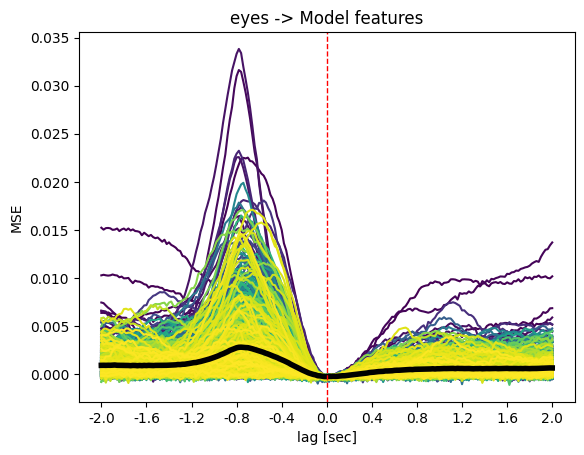

In [32]:
import matplotlib.pyplot as plt
import numpy as np

data = s.get_array()
n_lines = data.shape[0]
tick_step = 20
cmap = plt.get_cmap("viridis")  # choose your cmap
max_lag = cfg.max_lag
fs = s.get_fs()
ticks = np.arange(-max_lag, max_lag + 1, tick_step)
ticks_labels = np.round(ticks / fs, 2)
ticks+= max_lag
for i in range(n_lines):
    color = cmap(i / n_lines)
    plt.plot(data.T[:, i], color=color)#, label=labels1[i])

# mean in black (on top)
# ticks = np.arange(-cfg.max_lag-1, cfg.max_lag+1, tick_step) + cfg.max_lag
# ticks_labels = np.round(np.arange(-cfg.max_lag/s.get_fs(), (cfg.max_lag+1)/s.get_fs(), tick_step/s.get_fs()), 2)
plt.plot(data.mean(axis=0), linewidth=4, color="k")
plt.xticks(ticks, ticks_labels)
plt.axvline(data.shape[1]//2, color="r", linestyle="--", linewidth=1)
plt.title(f"eyes -> Model features")
plt.ylabel("MSE")
plt.xlabel("lag [sec]");

# plt.legend(fontsize=6)

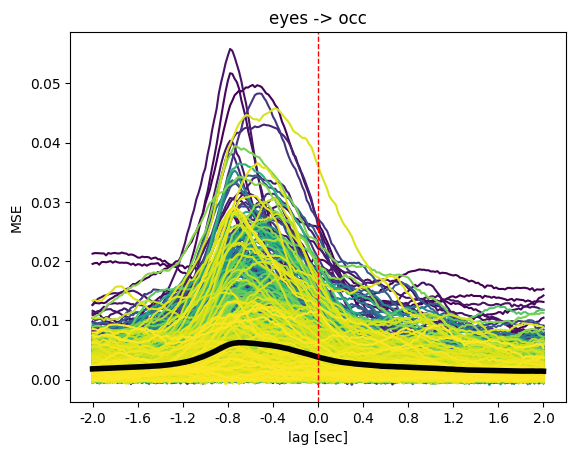

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

data = s.get_array()
n_lines = data.shape[0]
tick_step = 20
cmap = plt.get_cmap("viridis")  # choose your cmap
max_lag = cfg.max_lag
fs = s.get_fs()
ticks = np.arange(-max_lag, max_lag + 1, tick_step)
ticks_labels = np.round(ticks / fs, 2)
ticks+= max_lag
for i in range(n_lines):
    color = cmap(i / n_lines)
    plt.plot(data.T[:, i], color=color)#, label=labels1[i])

# mean in black (on top)
# ticks = np.arange(-cfg.max_lag-1, cfg.max_lag+1, tick_step) + cfg.max_lag
# ticks_labels = np.round(np.arange(-cfg.max_lag/s.get_fs(), (cfg.max_lag+1)/s.get_fs(), tick_step/s.get_fs()), 2)
plt.plot(data.mean(axis=0), linewidth=4, color="k")
plt.xticks(ticks, ticks_labels)
plt.axvline(data.shape[1]//2, color="r", linestyle="--", linewidth=1)
plt.title(f"eyes -> {cfg.sensors_group}")
plt.ylabel("MSE")
plt.xlabel("lag [sec]");

# plt.legend(fontsize=6)